# Implementacion de Nullclines

Codigo de ejemplo en python para implementar Nullclines

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

from scipy.integrate import solve_ivp

Grafica de Nullclines

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# Definir las constantes globales
vna = 50
vk = -77
vl = -54.4
gna = 120
gk = 36
gl = 0.3
c = 1
I = 20

# Definir las funciones
def m_inf(v):
    return a_m(v) / (a_m(v) + b_m(v))

def a_m(v):
    return 0.1 * (v + 40) / (1 - np.exp(-(v + 40) / 10))

def b_m(v):
    return 4 * np.exp(-(v + 65) / 18)

def a_n(v):
    return 0.01 * (v + 55) / (1 - np.exp(-(v + 55) / 10))

def b_n(v):
    return 0.125 * np.exp(-(v + 65) / 80)

def a_h(v): 
    return 0.07 * np.exp(-(v + 65) / 20)

def b_h(v): 
    return 1 / (1 + np.exp(-(v + 35) / 10))

def rhsV(n, v, I, dv):
    return ((I - gna * (m_inf(v))**3 * (0.8 - n) * (v - vna) - gk * n**4 * (v - vk) - gl * (v - vl)) / c) + dv

def rhsn(n, v, dn):
    return a_n(v) * (1 - n) - b_n(v) * n + dn


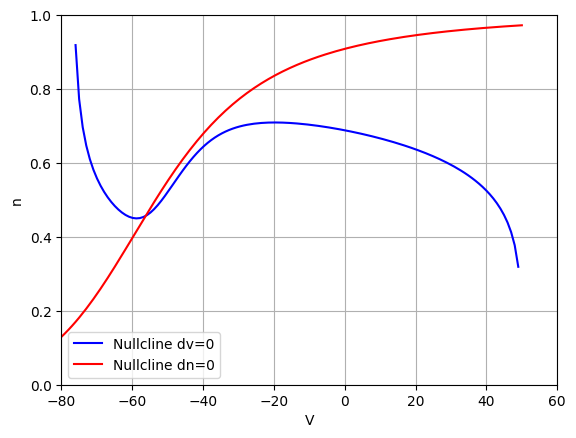

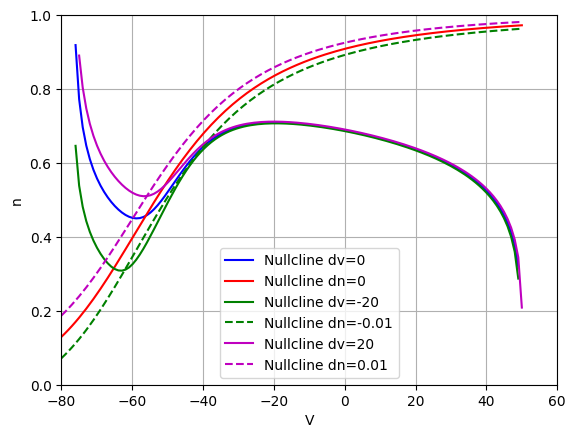

In [3]:
# Definir los rangos y listas de valores
vv = np.linspace(-80, 50, 130)
nullv = []
nulln = []
nulldv_n = []
nulldn_n = []
nulldv_p = []
nulldn_p = []

# Función auxiliar para encontrar un intervalo adecuado
def find_root(func, bracket, v, dv=0, dn=0):
    try:
        root = root_scalar(func, bracket=bracket, args=(v, I, dv, dn), method='brentq', xtol=1e-6)
        if root.converged:
            return root.root
        else:
            return np.nan
    except ValueError:
        return np.nan

# Evaluar los nullclines
for v in vv:
    nullv.append(find_root(lambda n, v, I, dv, dn: rhsV(n, v, I, dv), [0, 1], v, dv=0))
    nulln.append(find_root(lambda n, v, I, dv, dn: rhsn(n, v, dn), [0, 1], v, dn=0))

    nulldv_n.append(find_root(lambda n, v, I, dv, dn: rhsV(n, v, I, dv), [0, 1], v, dv=20))
    nulldn_n.append(find_root(lambda n, v, I, dv, dn: rhsn(n, v, dn), [0, 1], v, dn=0.01))

    nulldv_p.append(find_root(lambda n, v, I, dv, dn: rhsV(n, v, I, dv), [0, 1], v, dv=-20))
    nulldn_p.append(find_root(lambda n, v, I, dv, dn: rhsn(n, v, dn), [0, 1], v, dn=-0.01))

# Convertir listas a arrays para facilitar la manipulación
nullv = np.array(nullv)
nulln = np.array(nulln)
nulldv_n = np.array(nulldv_n)
nulldn_n = np.array(nulldn_n)
nulldv_p = np.array(nulldv_p)
nulldn_p = np.array(nulldn_p)

# Graficar los resultados
plt.figure(2)
plt.plot(vv, nullv, 'b', label='Nullcline dv=0')
plt.plot(vv, nulln, 'r', label='Nullcline dn=0')
plt.xlabel('V')
plt.ylabel('n')
plt.axis([-80, 60, 0, 1])
plt.legend()
plt.grid(True)

plt.figure(3)
plt.plot(vv, nullv, 'b', label='Nullcline dv=0')
plt.plot(vv, nulln, 'r', label='Nullcline dn=0')
plt.plot(vv, nulldv_p, 'g', label='Nullcline dv=-20')
plt.plot(vv, nulldn_p, 'g', linestyle='dashed', label='Nullcline dn=-0.01')
plt.plot(vv, nulldv_n, 'm', label='Nullcline dv=20')
plt.plot(vv, nulldn_n, 'm', linestyle='dashed', label='Nullcline dn=0.01')
plt.xlabel('V')
plt.ylabel('n')
plt.axis([-80, 60, 0, 1])
plt.legend()
plt.grid(True)

plt.show()


## Grafica de la trayectoria Nullclines

In [4]:
# Definir los rangos y listas de valores
vv = np.linspace(-80, 50, 130)
nullv = []
nulln = []

# Función auxiliar para encontrar un intervalo adecuado
def find_root(func, bracket, v, dv=0, dn=0):
    try:
        root = root_scalar(func, bracket=bracket, args=(v, I, dv, dn), method='brentq', xtol=1e-6)
        if root.converged:
            return root.root
        else:
            return np.nan
    except ValueError:
        return np.nan

# Evaluar los nullclines
for v in vv:
    nullv.append(find_root(lambda n, v, I, dv, dn: rhsV(n, v, I, dv), [0, 1], v, dv=0))
    nulln.append(find_root(lambda n, v, I, dv, dn: rhsn(n, v, dn), [0, 1], v, dn=0))

# Convertir listas a arrays para facilitar la manipulación
nullv = np.array(nullv)
nulln = np.array(nulln)


In [5]:
# Constants for the method
Cm = 1                     # membrane capacitance uF/cm^2
dt = 0.01                  # delta time in ms
t = np.arange(0, 60, dt)   # time array in ms

I = 15  # external current applyed

ENa=50      # mv Na reversal potential 
EK=-77      # mv K reversal potential 
El=-54.4    # mv Leakage reversal potential 
gbarNa=120  # mS/cm^2 Na conductance 
gbarK=36    # mS/cm^2 K conductance 
gbarl=0.3   # mS/cm^2 Leakage conductance
V_rest = -60

n_inf = np.zeros(len(t))
m_inf = np.zeros(len(t))
h_inf = np.zeros(len(t))
Vfn = np.zeros(len(t))
Vfn[0] = np.array(V_rest)  # Valor inicial de la solucion

m_inf[0] = a_m(Vfn[0])/(a_m(Vfn[0])+b_m(Vfn[0]))    # Initial m-value
n_inf[0] = a_n(Vfn[0])/(a_n(Vfn[0])+b_n(Vfn[0]))    # Initial n-value
h_inf[0] = a_h(Vfn[0])/(a_h(Vfn[0])+b_h(Vfn[0]))    # Initial h-value


for i in range(0, len(t) - 1):

    # Euler method
    m_inf[i+1]= a_m(Vfn[i])/(a_m(Vfn[i])+b_m(Vfn[i]))   # first assumption
    n_inf[i+1]= n_inf[i]+dt*((a_n(Vfn[i])*(1-n_inf[i]))-(b_n(Vfn[i])*n_inf[i])) 
    h_inf[i+1]= 0.8-n_inf[i+1]
    
    gNafn = gbarNa*h_inf[i]*m_inf[i]**3
    gKfn  = gbarK*n_inf[i]**4
    glfn  = gbarl
    
    INa_fn = gNafn*(Vfn[i]-ENa)
    IK_fn  = gKfn*(Vfn[i]-EK)
    Il_fn  = glfn*(Vfn[i]-El)
    
    # Euler method to find the next voltage value
    Vfn[i+1]=Vfn[i]+(dt)*((1/Cm)*(I-(INa_fn+IK_fn+Il_fn)))




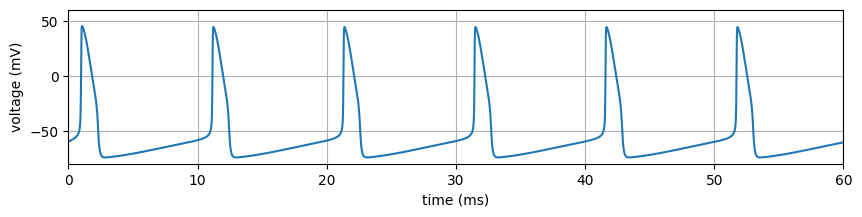

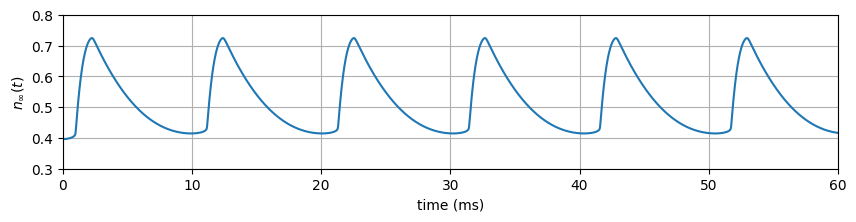

In [6]:
# Generar datos ficticios para T y Y
T = t
Y = np.zeros((len(t), 2))
Y[:, 0] = Vfn  # Datos ficticios para V, ajustar según sea necesario
Y[:, 1] = n_inf  # Datos ficticios para n, ajustar según sea necesario

plt.figure(figsize=(10,2))
plt.plot(T, Y[:,0])
#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
#plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.xlim([0, 60])
plt.ylim([-80, 60])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

# plt.savefig("output/FHN_voltage.pdf", format="pdf", bbox_inches="tight")


# 
plt.figure(figsize=(10,2))
plt.plot(T, Y[:,1])

#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
#plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time (ms)')
plt.ylabel('$n_\infty(t)$')
plt.xlim([0, 60])
plt.ylim([0.3, 0.8])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

# plt.savefig("output/FHN_nparam.pdf", format="pdf", bbox_inches="tight")


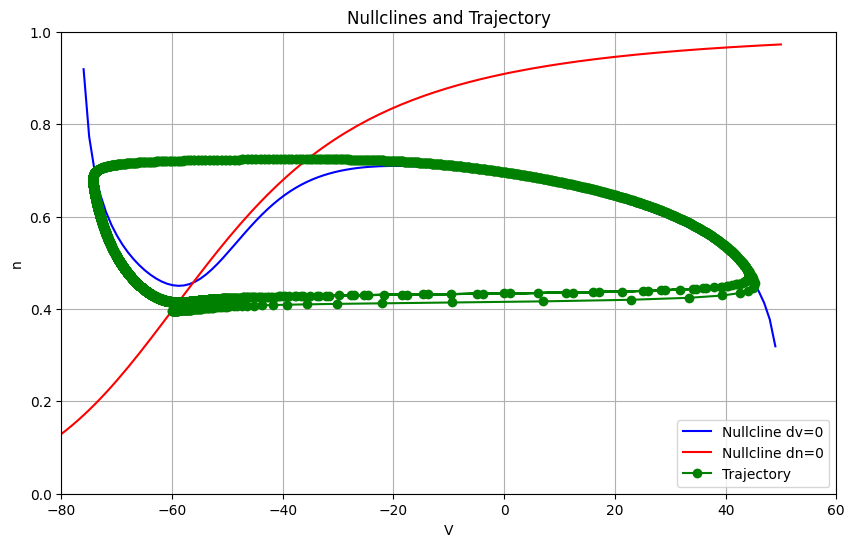

In [7]:
# Graficar los nullclines y la trayectoria
plt.figure(figsize=(10, 6))

# Nullclines
plt.plot(vv, nullv, 'b', label='Nullcline dv=0')
plt.plot(vv, nulln, 'r', label='Nullcline dn=0')

# Trayectoria
plt.plot(Y[:, 0], Y[:, 1], 'g-o', label='Trajectory')

plt.xlabel('V')
plt.ylabel('n')
plt.axis([-80, 60, 0, 1])
plt.legend()
plt.title('Nullclines and Trajectory')
plt.grid(True)

plt.show()


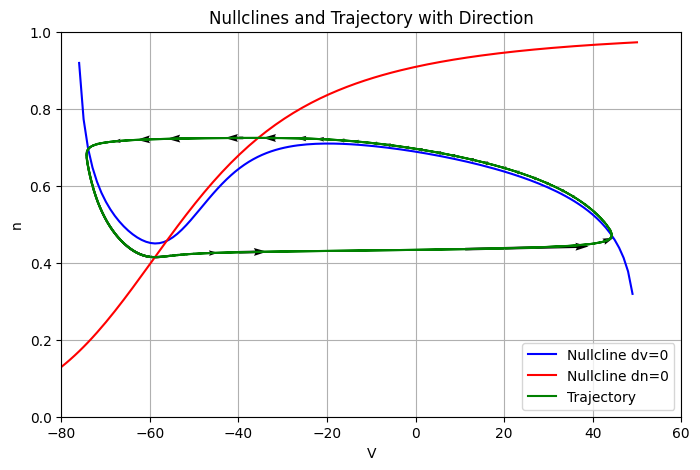

In [8]:
ini = 1000
fin = 3000

# Calcular las diferencias entre puntos para las flechas
dY = np.diff(Y[:,:], axis=0)

# Graficar los nullclines y la trayectoria
plt.figure(figsize=(8, 5))

# Nullclines
plt.plot(vv, nullv, 'b', label='Nullcline dv=0')
plt.plot(vv, nulln, 'r', label='Nullcline dn=0')

# Trayectoria
plt.plot(Y[ini:fin, 0], Y[ini:fin, 1], 'g', label='Trajectory')

# Flechas para indicar la dirección del tiempo
skip = 10  # saltar puntos para no sobrecargar el gráfico con flechas
plt.quiver(Y[ini:fin-1:skip, 0], Y[ini:fin-1:skip, 1], dY[ini:fin:skip, 0], dY[ini:fin:skip, 1], angles='xy', scale_units='xy', scale=.5, color='black')

plt.xlabel('V')
plt.ylabel('n')
plt.axis([-80, 60, 0, 1])
plt.legend()
plt.title('Nullclines and Trajectory with Direction')
plt.grid(True)

plt.show()

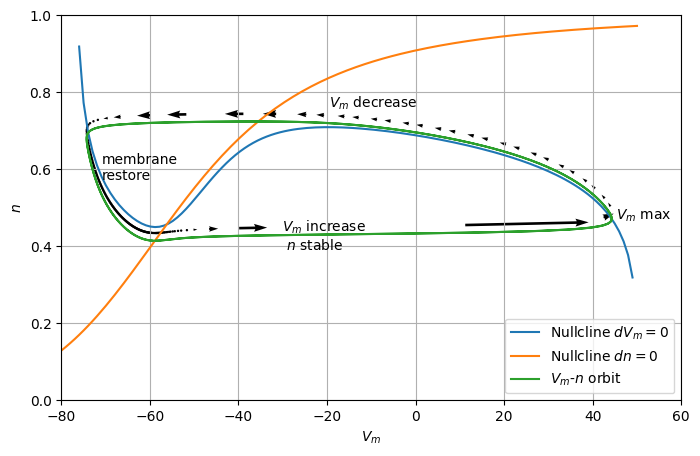

In [10]:
# Calcular las diferencias entre puntos para las flechas
dY = np.diff(Y[:,:], axis=0)

# Definir el rango de interés
ini = 1000
fin = 3000

# Graficar los nullclines y la trayectoria
plt.figure(figsize=(8, 5))

# Nullclines
plt.plot(vv, nullv, label='Nullcline $dV_m=0$')
plt.plot(vv, nulln, label='Nullcline $dn=0$')

# Trayectoria
plt.plot(Y[ini:fin, 0], Y[ini:fin, 1], label='$V_m$-$n$ orbit')

# Flechas para indicar la dirección del tiempo
skip = 10  # saltar puntos para no sobrecargar el gráfico con flechas
arrow_offset = 0.02  # desplazamiento de las flechas

plt.quiver(Y[ini:fin-1:skip, 0] + arrow_offset, Y[ini:fin-1:skip, 1] + arrow_offset, 
           dY[ini:fin:skip, 0], dY[ini:fin:skip, 1], 
           angles='xy', scale_units='xy', scale=.5, color='black')

# Añadir etiquetas
plt.text(Y[95, 0], Y[95, 1] - arrow_offset, '$V_m$ increase\n $n$ stable', fontsize=10)
plt.text(Y[105, 0], Y[105, 1] + arrow_offset, '$V_m$ max', fontsize=10)
plt.text(Y[210, 0], Y[210, 1] + 2*arrow_offset, '$V_m$ decrease', fontsize=10)
plt.text(Y[500, 0], Y[500, 1] + 2*arrow_offset, 'membrane\nrestore', fontsize=10)

plt.xlabel('$V_m$')
plt.ylabel('$n$')
plt.axis([-80, 60, 0, 1])
plt.legend()
#plt.title('Nullclines and Trajectory with Direction')
plt.grid(True)

#plt.show()

plt.savefig("output/nullclines.pdf", format="pdf", bbox_inches="tight")